# Setup


In [77]:
%matplotlib inline

import os, sys, warnings, math, pickle

import numpy as np
import scipy as sp
from scipy.spatial import distance
from scipy.ndimage import uniform_filter1d
from scipy import stats
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from sklearn.decomposition import PCA
import pandas as pd
import tqdm.std
sys.modules['tqdm.autonotebook'] = tqdm.std
from tqdm.std import tqdm
from tqdm.notebook import tqdm as tqdmnb
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
import torch
import torch.nn as nn

import src.utils as utils
from src.neural_network import (ModelStateManager, ModelDataManager,
                                create_rnn_and_env_for_model, run_testing, run_testing_rest,
                                infer_test_timing)
from src.utils import get_weight_masks_schaefer, get_params_dataframe

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


# Files and parameters


In [78]:
# directories and files
model_params_name = 'model_params_202603bp'
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        # modeldir = os.path.join('/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model', model_params_name)
        modeldir = os.path.join('/Volumes/Sabrent_2TB/rutgers/neuro_rnn/data', model_params_name)
        fmridir = '/Volumes/Sabrent_2TB/rutgers/HCP/fmri'
        outdir = modeldir
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model'
        outdir = modeldir
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
        outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

model_params_file = os.path.join(datadir, model_params_name + '.csv')

check_only = False
verbose = True
save_figs = False

# select rows from model params CSV
rows_to_plot = None
rows_to_plot = [0, 1, 4, 5, 6, 7,    8,  9, 12, 13, 14, 15]
rows_to_plot = [2, 3, 4, 5, 6, 7,   10, 11, 12, 13, 14, 15]

model_params, task_names, n_tasks, kernel_labels, n_kernels = utils.get_params_dataframe(
    model_params_file, rows=rows_to_plot, verbose=verbose)
n_models = len(model_params)


# kernel files
sa_kernel_file = os.path.join(datadir, 'schaefer200_sa-axis.npy')
ut_kernel_file = os.path.join(datadir, 'schaefer200_ut-axis.npy')
sf_kernel_file = os.path.join(datadir, 'schaefer200_cyto.npy')
eucl_kernel_file = os.path.join(datadir, 'schaefer200_centroids.csv')

# fMRI files
tfmri_file = '/Users/ahmad/data/rutgers/hcp/hcpya_tfmri.pkl'
fmri_data_file = os.path.join(fmridir, 'HCP_YA_Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S1_rest.npy') 
fmri_data_df_file = os.path.join(fmridir, 'HCP_YA_Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S1_rest_df.csv') 

display(model_params)


Tasks:
------
GoNogo-v0-Del_200_100_Dec_300
DelayMatchSampleDistractor1D-v0
 
Kernel types:
-------------
Unmasked Reg. 
Masked Reg. 
Masked S-F
Masked Eucl.
Masked S-A
Masked U-T
 
DataFrame keys:
---------------
task
seq_len_multi
time_step
alpha
rec_noise
init_hh_w
rnn_model
hidden_size
batch_size
learning_rate
n_epochs
reg_type
reg_weight
kernel_type
kernel_normalization
mask_weights
n_runs
kernel_label
task_label
task_index
kernel_index
task_no_modifier
task_modifier
task_with_modifier
n_io
seq_len
config
file_str_models
file_str_outputs
env_kwargs
model_index
 


,task,seq_len_multi,time_step,alpha,rec_noise,init_hh_w,rnn_model,hidden_size,batch_size,learning_rate,...,task_no_modifier,task_modifier,task_with_modifier,n_io,seq_len,config,file_str_models,file_str_outputs,env_kwargs,model_index
0,GoNogo-v0-Del_200_100_Dec_300,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,GoNogo-v0,Del_200_100_Dec_300,GoNogo-v0-Del_200_100_Dec_300,na,120,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,"{'dt': 50, 'timing': {'fixation': 200, 'stimul...",0
1,GoNogo-v0-Del_200_100_Dec_300,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,GoNogo-v0,Del_200_100_Dec_300,GoNogo-v0-Del_200_100_Dec_300,14-27,120,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,"{'dt': 50, 'timing': {'fixation': 200, 'stimul...",1
2,GoNogo-v0-Del_200_100_Dec_300,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,GoNogo-v0,Del_200_100_Dec_300,GoNogo-v0-Del_200_100_Dec_300,14-27,120,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,"{'dt': 50, 'timing': {'fixation': 200, 'stimul...",2
3,GoNogo-v0-Del_200_100_Dec_300,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,GoNogo-v0,Del_200_100_Dec_300,GoNogo-v0-Del_200_100_Dec_300,14-27,120,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,"{'dt': 50, 'timing': {'fixation': 200, 'stimul...",3
4,GoNogo-v0-Del_200_100_Dec_300,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,GoNogo-v0,Del_200_100_Dec_300,GoNogo-v0-Del_200_100_Dec_300,14-27,120,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,"{'dt': 50, 'timing': {'fixation': 200, 'stimul...",4
5,GoNogo-v0-Del_200_100_Dec_300,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,GoNogo-v0,Del_200_100_Dec_300,GoNogo-v0-Del_200_100_Dec_300,14-27,120,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,GoNogo-v0-Del_200_100_Dec_300-120-rnn-tanh-100...,"{'dt': 50, 'timing': {'fixation': 200, 'stimul...",5
6,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,na,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",6
7,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,14-27,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",7
8,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,14-27,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",8
9,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,14-27,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",9


# Load axes and kernels


In [79]:
hidden_size = 100

# euclidean
centroids = pd.read_csv(eucl_kernel_file)
centroids = centroids[:hidden_size]  # pull out left hemisphere
roi_names = centroids['ROI Name'].str.replace('7Networks_LH_', '')
centroids.set_index("ROI Name", inplace=True)
distance_matrix = distance.pdist(centroids, "euclidean")
distance_matrix = distance.squareform(distance_matrix)
distance_matrix_eucl = utils.normalize_x(distance_matrix)

# sa axis
sa_axis = np.load(sa_kernel_file)
sa_axis = sa_axis[:hidden_size]
distance_matrix = utils.get_brainmap_distance(brain_map=sa_axis)
distance_matrix_sa = utils.normalize_x(distance_matrix)

# ut axis
ut_axis = np.load(ut_kernel_file)
ut_axis = ut_axis[:hidden_size]
distance_matrix = utils.get_brainmap_distance(brain_map=ut_axis)
distance_matrix_ut = utils.normalize_x(distance_matrix)

# sf axis
sf_axis = np.load(sf_kernel_file)
sf_axis = sf_axis[:hidden_size]
distance_matrix = utils.get_brainmap_distance(brain_map=sf_axis)
distance_matrix_sf = utils.normalize_x(distance_matrix)

# node groups (input / internal / output)
n_io = utils.get_n_io(mask_weights=True, hidden_size=hidden_size)
n_nodes_in = int(n_io.split('-')[0])
n_nodes_out = int(n_io.split('-')[1])
n_nodes_inter = hidden_size - n_nodes_in - n_nodes_out
n_nodes = n_nodes_in + n_nodes_inter + n_nodes_out

node_groups = np.concatenate((np.ones((n_nodes_in,)) * 0,
                              np.ones((n_nodes_inter,)) * 1,
                              np.ones((n_nodes_out,)) * 2), axis=0)
node_groups_labels = ['in' if v == 0 else 'inter' if v == 1 else 'out' for v in node_groups]

# node colors
col_input = np.array([228, 149, 145]) / 255
col_bys = np.array([129, 223, 180]) / 255
col_output = np.array([122, 139, 165]) / 255
colors = np.concatenate((np.tile(col_input, [n_nodes_in, 1]),
                         np.tile(col_bys, [n_nodes_inter, 1]),
                         np.tile(col_output, [n_nodes_out, 1])), axis=0)
colors_categ = np.unique(colors, axis=0)

print(f'Node groups: {n_nodes_in} input, {n_nodes_inter} internal, {n_nodes_out} output')


Node groups: 14 input, 59 internal, 27 output


# Helper functions


In [80]:
def compute_ac_acw_aca(ts, nlags=None, fit=False, threshold_0=0.0):
    """Calculate the signal autocorrelation (lagged correlation).

    Parameters
    ----------
    ts : np.array (n_timepoints,)
        Time series.
    nlags : int (default=None)
        Number of lags to compute acf over.
    fit : bool (default=False)
        If True, fit an exponential decay to the raw ACF and use the fitted
        curve to compute acw/aca metrics instead of the raw ACF values.
    threshold_0 : float (default=0.0)
        Threshold for acw_0/aca_0 computation. Useful when AC approaches but
        does not cross zero.

    Returns
    -------
    ac : np.array (n_lags,)
        Time lagged (auto)correlation. If fit=True, returns the fitted
        exponential curve instead of the raw ACF.
    acw_50 : int
        Lag at which AC drops below 0.5. len(ac) if threshold never reached.
    acw_0 : int
        Lag at which AC drops below threshold_0. len(ac) if threshold never reached.
    aca_50 : float
        Area under the AC curve up until acw_50. len(ac) if threshold never reached.
    aca_0 : float
        Area under the AC curve up until acw_0. len(ac) if threshold never reached.
    """
    # compute auto correlation function using statsmodels
    ac = acf(ts, nlags=nlags)[:-1]
    n = len(ac)

    if fit:
        lags = np.arange(n)
        try:
            popt, _ = curve_fit(utils.exp_decay, lags, ac, p0=[10, 1], maxfev=5000)
            ac = utils.exp_decay(lags, *popt)
        except RuntimeError:
            pass  # fitting failed; fall back to raw ACF

    # get data for the 50% point
    if np.any(ac < 0.5):
        ac_trim_50 = ac[:np.where(ac < 0.5)[0][0]]
        acw_50 = ac_trim_50.shape[0]
        aca_50 = ac_trim_50.sum(axis=0)
    else:
        acw_50 = n
        aca_50 = ac.sum(axis=0)

    # get data for the 0 point
    if np.any(ac < threshold_0):
        ac_trim_0 = ac[:np.where(ac < threshold_0)[0][0]]
        acw_0 = ac_trim_0.shape[0]
        aca_0 = ac_trim_0.sum(axis=0)
    else:
        acw_0 = n
        aca_0 = ac.sum(axis=0)

    return ac, acw_50, acw_0, aca_50, aca_0


In [81]:
def compute_task_variance(hidden_activity, mask=None):
    """Compute task, temporal, and spatial variance of hidden activity.

    Parameters
    ----------
    hidden_activity : np.array (n_trials, n_timepoints, n_nodes)
        Hidden activity across trials.
    mask : np.array (n_nodes,), optional
        Boolean mask to select a subset of nodes.

    Returns
    -------
    outputs : dict
        Dictionary with keys: hidden_activity_task_var, hidden_activity_temp_var,
        hidden_activity_spat_var, hidden_activity_mean.
    """
    if mask is not None:
        hidden_activity = hidden_activity[:, :, mask]

    outputs = dict()
    outputs['hidden_activity_task_var'] = hidden_activity.var(axis=0)
    outputs['hidden_activity_temp_var'] = hidden_activity.var(axis=1)
    outputs['hidden_activity_spat_var'] = hidden_activity.var(axis=2)
    outputs['hidden_activity_mean'] = hidden_activity.mean(axis=0)

    return outputs


In [82]:
def categorical_kde_plot(df, variable, category, category_order=None, horizontal=False,
                        rug=True, color_palette=None, title=None, refline=None, ttest=False):
    """Draw a categorical KDE plot."""
    if category_order is None:
        categories = list(df[category].unique())
    else:
        categories = category_order[:]

    figsize = (8, 0.65 * len(categories))

    fig, axes = plt.subplots(
        nrows=len(categories) if horizontal else 1,
        ncols=1 if horizontal else len(categories),
        figsize=figsize[::-1] if not horizontal else figsize,
        sharex=horizontal,
        sharey=not horizontal,
    )
    if len(categories) == 1:
        axes = [axes]

    for i, (cat, ax) in enumerate(zip(categories, axes)):
        plot_data = df[df[category] == cat]
        if ttest:
            t_stat, p_val = stats.ttest_1samp(plot_data[variable].dropna(), refline if refline is not None else 0)
            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                stars = ''
            label = f"{cat} {stars}" if stars else cat
            print(f"{cat}: t = {t_stat:.2f}, p = {p_val:.2e}")
        else:
            label = cat
        sns.kdeplot(data=plot_data, ax=ax,
                    x=variable if horizontal else None,
                    y=None if horizontal else variable,
                    color=color_palette[i] if color_palette is not None else "lightslategray",
                    bw_adjust=1, clip_on=False, fill=True, alpha=1, linewidth=1)
        ax.axvline(x=plot_data[variable].mean(), ymax=0.5, color='lightslategray')

        if rug:
            sns.rugplot(data=df[df[category] == cat],
                        x=variable if horizontal else None,
                        y=None if horizontal else variable,
                        ax=ax, color="white", height=0.15, linewidth=0.5)

        keep_variable_axis = (i == len(fig.axes) - 1) if horizontal else (i == 0)
        # format axis
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis='both', which='major', pad=0)
        if horizontal:
            ax.set_ylabel(None)
            lim = ax.get_ylim()
            ax.set_yticks([(lim[0] + lim[1]) / 2])
            ax.set_yticklabels([label])
            if not keep_variable_axis:
                ax.get_xaxis().set_visible(False)
                ax.spines["bottom"].set_visible(False)
        else:
            ax.set_xlabel(None)
            lim = ax.get_xlim()
            ax.set_xticks([(lim[0] + lim[1]) / 2])
            ax.set_xticklabels([label])
            if not keep_variable_axis:
                ax.get_yaxis().set_visible(False)
                ax.spines["left"].set_visible(False)
                
        if refline is not None:
            if horizontal:
                ax.axvline(x=refline, color=[0.5]*3, linestyle='--')
            else:
                ax.axhline(y=refline, color=[0.5]*3, linestyle='--')
    
    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()
    return fig


In [83]:
def pca_hidden_activity(hidden_activity, n_components=3, normalize_data=True):
    """Perform PCA on RNN hidden activity data.

    Parameters
    ----------
    hidden_activity : list
        List of trial data where each trial has shape [time, nodes].
    n_components : int
        Number of principal components to compute.
    normalize_data : bool
        Mean-center data before running PCA.

    Returns
    -------
    pca : PCA object
    hidden_activity_pc : list of transformed trial data
    n_trials, n_timepoints, n_nodes : int
    variance_explained : dict
    """
    if not isinstance(hidden_activity, list):
        raise TypeError('hidden_activity must be a list of trial data')

    n_trials = len(hidden_activity)
    n_timepoints, n_nodes = hidden_activity[0].shape

    hidden_activity_mat = np.reshape(np.array(hidden_activity),
                                     (n_trials * n_timepoints, n_nodes))

    if normalize_data:
        hidden_activity_mat = hidden_activity_mat - np.mean(hidden_activity_mat, axis=0)

    pca = PCA(n_components=n_components)
    pca.fit(hidden_activity_mat)

    variance_explained = {
        'each': pca.explained_variance_ratio_,
        'cumul': np.cumsum(pca.explained_variance_ratio_),
        'total': np.sum(pca.explained_variance_ratio_)
    }

    hidden_activity_pc = [pca.transform(trial) for trial in hidden_activity]

    return pca, hidden_activity_pc, n_trials, n_timepoints, n_nodes, variance_explained


def project_fmri_to_rnn_pc_space(fmri_data, pca_fitted, normalize_data=True):
    """Project fMRI data into PC space derived from RNN hidden activity."""
    if fmri_data.ndim != 2:
        raise ValueError("fMRI data must be 2D array with shape [time, nodes]")

    n_nodes = fmri_data.shape[1]
    expected_nodes = pca_fitted.n_features_in_

    if n_nodes != expected_nodes:
        raise ValueError(f"fMRI data has {n_nodes} nodes, but PCA was fitted on {expected_nodes} nodes")

    if normalize_data:
        fmri_data = fmri_data - np.mean(fmri_data, axis=0)

    fmri_pc = fmri_data @ pca_fitted.components_.T

    # calculate variance explained
    total_variance = np.sum(np.power(fmri_data, 2), axis=None)
    pc_variances = np.sum(np.power(fmri_pc, 2), axis=0)
    variance_explained_each = pc_variances / total_variance

    variance_explained = {
        'each': variance_explained_each,
        'cumul': np.cumsum(variance_explained_each),
        'total': np.sum(variance_explained_each)
    }

    return fmri_pc, variance_explained


In [84]:
def set_font_size(font_size=12):
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size+1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size-1,
        'ytick.labelsize': font_size-1,
        'legend.fontsize': font_size,
        'figure.titlesize': font_size+2,
    })

# Load trained models


In [85]:
device = torch.device('cpu')

if check_only:

    found_count = 0
    for model_idx in range(n_models):
        this = model_params.iloc[model_idx]
        file_path_models = os.path.join(modeldir, this.file_str_models)
        file_path_outputs = os.path.join(modeldir, this.file_str_outputs)
        if os.path.isfile(file_path_models):
            found_count += 1
        else:
            print(f'Not found ... {this.file_str_models} ({model_idx})')
    print(f'Found {found_count}/{n_models} files.')

else:

    trained_models_all = []
    model_accuracy_all = []

    for model_idx in tqdm(range(n_models), desc='Loading data'):

        this = model_params.iloc[model_idx]
        utils.check_if_supported(task=this.task_no_modifier, modifier=this.task_modifier)

        file_path_models = os.path.join(modeldir, this.file_str_models)
        file_path_outputs = os.path.join(modeldir, this.file_str_outputs)

        # remove delay variability for testing
        if 'delay' in this['env_kwargs']['timing']:
            d, _ = utils.parse_task_modifier(this.task_modifier)
            try:
                this['env_kwargs']['timing']['delay'] = d[0]
            except:
                pass

        # get model info
        state_manager = ModelStateManager(file_path_models)
        n_runs, logged_epochs, keys_per_epoch = state_manager.get_info()
        n_runs = np.min((n_runs, 100))

        # create rnn and dataset for each trained run
        trained_models = []
        for run in range(n_runs):
            dataset, rnn = create_rnn_and_env_for_model(this,
                                                         run=run,
                                                         epoch=logged_epochs[-1],
                                                         data_dir=modeldir,
                                                         device=device)
            trained_models.append({'dataset': dataset, 'rnn': rnn})
        trained_models_all.append(trained_models)

        # # load test accuracy
        # output_manager = ModelDataManager(file_path_outputs)
        # test_accuracy_all_runs = output_manager.load_key_across_runs('test_accuracy', epoch=logged_epochs[-1])
        # model_accuracy_all.append(test_accuracy_all_runs)

Loading data: 100%|██████████| 12/12 [00:40<00:00,  3.33s/it]


# Load fMRI data

In [86]:
n_fmri_subj = 100

## Resting state fMRI

In [87]:
fmri_rest_data_df = pd.read_csv(fmri_data_df_file)
use_fmri_rest = pd.concat((fmri_rest_data_df.rfMRI_available,
                      fmri_rest_data_df.rfMRI_REST1_LR,
                      fmri_rest_data_df.rfMRI_REST1_RL,
                      fmri_rest_data_df.rfMRI_REST2_LR,
                      fmri_rest_data_df.rfMRI_REST2_RL),
                     axis=1).to_numpy()
use_fmri_rest = np.all(use_fmri_rest,axis=1)
fmri_rest_data = np.load(fmri_data_file)
fmri_rest_ts = fmri_rest_data[:,16:116,0,use_fmri_rest]
# n_fmri_rest_subj = np.min((fmri_rest_ts.shape[2],100))
fmri_rest_nsubj = n_fmri_subj
fmri_rest_ts = fmri_rest_ts[:, :, :fmri_rest_nsubj]
fmri_rest_nsteps = fmri_rest_ts.shape[0]
print(f'fMRI rest shape: {fmri_rest_ts.shape}')
print(f'fMRI rest time steps: {fmri_rest_nsteps}')
print(f'fMRI rest N subjects: {fmri_rest_nsubj}')

fMRI rest shape: (1200, 100, 100)
fMRI rest time steps: 1200
fMRI rest N subjects: 100


## Task fMRI

In [88]:
with open(tfmri_file, 'rb') as f:
    tfmri = pickle.load(f)
fmri_task_key = 'tfMRIWMLR'
fmri_task_parc = 'Schaefer2007'
fmri_task_subjnames = list(tfmri.keys())
# fmri_task_nsubj = 200
fmri_task_nsubj = n_fmri_subj
fmri_task_nsteps = np.min([tfmri[fmri_task_subjnames[i]][fmri_task_parc][fmri_task_key].shape[0]
                       for i in range(fmri_task_nsubj)])
fmri_task_ts = np.zeros((fmri_task_nsteps, n_nodes, fmri_task_nsubj))
for i in range(fmri_task_nsubj):
    xxx = tfmri[fmri_task_subjnames[i]][fmri_task_parc][fmri_task_key][:fmri_task_nsteps, :n_nodes]
    fmri_task_ts[:, :, i] = xxx - np.mean(xxx, axis=0)
print(f'fMRI task shape: {fmri_task_ts.shape}')
print(f'fMRI task time steps: {fmri_task_nsteps}')
print(f'fMRI task N subjects: {fmri_task_nsubj}')

fMRI task shape: (405, 100, 100)
fMRI task time steps: 405
fMRI task N subjects: 100


# Test models


In [89]:
# define number of test trials
n_trials = 100

# define window size for smoothing of noise input during resting state testing
smooth_noise = 0

def test_one_model(model_data, n_trials, smooth_noise):
    torch.set_num_threads(1)  # prevent thread contention across parallel workers

    test_model_task = []
    test_model_rest = []

    for run in range(len(model_data)):
        dataset = model_data[run]['dataset']
        rnn = model_data[run]['rnn']

        # test on task trials
        accuracy, inputs, labels, hidden_activity, output_activity, info = run_testing(
            dataset=dataset, model=rnn, n_trials=n_trials, verbose=False)
        test_model_task.append({
            'accuracy': accuracy,
            'inputs': inputs,
            'labels': labels,
            'hidden_activity': hidden_activity,
            'output_activity': output_activity,
            'info': info
        })

        # test on noise inputs (resting state)
        inputs_rest, hidden_activity_rest, output_activity_rest = run_testing_rest(
            rnn, smooth_noise=smooth_noise, noise_mean=1, noise_sd=0.1,
            n_steps=fmri_rest_nsteps, fix_input_channels=[])
        test_model_rest.append({
            'inputs': inputs_rest,
            'hidden_activity': hidden_activity_rest,
            'output_activity': output_activity_rest
        })

    return test_model_task, test_model_rest

with tqdm_joblib(tqdm(total=n_models, disable=True), desc='Testing models', gui=False):
    results = Parallel(n_jobs=-1)(
        delayed(test_one_model)(trained_models_all[model_idx], n_trials, smooth_noise)
        for model_idx in range(n_models)
    )

test_data_task = [r[0] for r in results]
test_data_rest = [r[1] for r in results]

Testing models: 100%|██████████| 12/12 [01:05<00:00,  5.50s/it]


# PCA analysis


## Set number of PCs

In [90]:
n_pc = 5

## Run PCA on trained models

In [91]:
pca_hidden_task = list()
pca_hidden_rest = list()
test_accuracy_pca = list()

for model_idx in range(n_models):
    pca_hidden_task_model = list()
    pca_hidden_rest_model = list()
    n_runs = len(test_data_task[model_idx])
    test_accuracy_model = np.zeros((n_runs))
    this = model_params.iloc[model_idx]
    print(f"{this.task_no_modifier} -- {this.kernel_label}")
    ve_task = np.zeros((n_runs, 1))
    ve_rest = np.zeros((n_runs, 1))

    for run_idx in tqdm(range(n_runs), desc=f'Model {model_idx+1}/{n_models}'):
        
        # task PCA
        pca, hpc, nt, ntp, nn, var_exp = pca_hidden_activity(
            hidden_activity=test_data_task[model_idx][run_idx]['hidden_activity'],
            n_components=n_pc, normalize_data=True)

        trial_categ = test_data_task[model_idx][run_idx]['info'].ground_truth.to_numpy()
        categs = np.unique(trial_categ)
        pca_by_categ = dict()
        for c in categs:
            pc_sum = np.zeros((ntp, n_pc))
            n_t = 0
            for t in range(nt):
                if trial_categ[t] == c:
                    pc_sum += hpc[t]
                    n_t += 1
            pca_by_categ[str(c)] = pc_sum / n_t

        run_accuracy = test_data_task[model_idx][run_idx]['accuracy']
        test_accuracy_model[run_idx] = run_accuracy
        pca_hidden_task_model.append({
            'pca': pca,
            'hidden_pc': hpc,
            'n_trials': nt,
            'n_time_points': ntp,
            'n_nodes': nn,
            'var_exp': var_exp,
            'hidden_pc_categ': pca_by_categ,
            'accuracy': run_accuracy
        })
        ve_task[run_idx] = var_exp['total']
        
        # rest PCA
        pca, hpc, nt, ntp, nn, var_exp = pca_hidden_activity(
            hidden_activity=[test_data_rest[model_idx][run_idx]['hidden_activity']],
            n_components=n_pc, normalize_data=True)
        
        pca_hidden_rest_model.append({
            'pca': pca,
            'hidden_pc': hpc,
            'n_time_points': ntp,
            'n_nodes': nn,
            'var_exp': var_exp
        })
        ve_rest[run_idx] = var_exp['total']

    pca_hidden_task.append(pca_hidden_task_model)
    pca_hidden_rest.append(pca_hidden_rest_model)
    test_accuracy_pca.append(test_accuracy_model)
    print(f'Mean variance explained (task): {ve_task.mean()*100:.2f}%')
    print(f'Mean variance explained (rest): {ve_rest.mean()*100:.2f}%')
    print(' ')


GoNogo-v0 -- Unmasked Reg. 


Model 1/12: 100%|██████████| 100/100 [00:01<00:00, 83.74it/s]


Mean variance explained (task): 99.54%
Mean variance explained (rest): 97.05%
 
GoNogo-v0 -- Masked Reg. 


Model 2/12: 100%|██████████| 100/100 [00:00<00:00, 103.80it/s]


Mean variance explained (task): 99.10%
Mean variance explained (rest): 98.10%
 
GoNogo-v0 -- Masked S-F


...

Mean variance explained (task): 74.03%
Mean variance explained (rest): 97.11%
 
DelayMatchSampleDistractor1D-v0 -- Masked S-A


Model 11/12: 100%|██████████| 100/100 [00:02<00:00, 41.90it/s]


Mean variance explained (task): 74.85%
Mean variance explained (rest): 98.27%
 
DelayMatchSampleDistractor1D-v0 -- Masked U-T


Model 12/12: 100%|██████████| 100/100 [00:02<00:00, 41.89it/s]

Mean variance explained (task): 73.83%
Mean variance explained (rest): 97.44%
 


## Run PCA on task fMRI


100%|██████████| 100/100 [00:00<00:00, 341.15it/s]


Median within-subject variance explained (task): 63.61%


100%|██████████| 100/100 [00:07<00:00, 13.59it/s]


Median between-subject variance explained (task): 41.93%


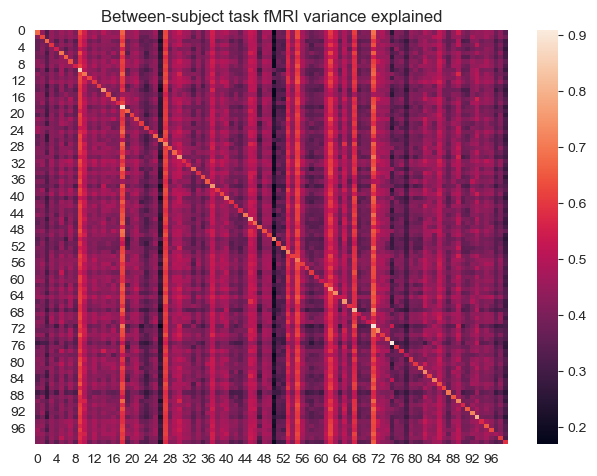

In [92]:
pca_fmri_task = list()
pca_fmri_task_var_exp = np.zeros((n_fmri_subj,))

for si in tqdm(range(n_fmri_subj)):
    this_fmri = fmri_task_ts[:, :, si]
    pca = PCA(n_components=n_pc)
    pca.fit(this_fmri)

    variance_explained = {
        'each': pca.explained_variance_ratio_,
        'cumul': np.cumsum(pca.explained_variance_ratio_),
        'total': np.sum(pca.explained_variance_ratio_)
    }
    pca_fmri_task.append({'pca': pca, 'var_exp': variance_explained})
    pca_fmri_task_var_exp[si] = variance_explained['total']

print(f'Median within-subject variance explained (task): {100*np.median(pca_fmri_task_var_exp):.2f}%')

# compute inter-subject variance explained (baseline)
N = n_fmri_subj
fmri_task_intersubj_var_exp_all = np.zeros((N, N))
for s1 in tqdm(range(N)):
    x1 = fmri_task_ts[:, :, s1]
    p1 = pca_fmri_task[s1]['pca']
    for s2 in range(N):
        x2 = fmri_task_ts[:, :, s2]
        x2_pc = x2 @ p1.components_.T
        total_var = np.sum(np.power(x2, 2), axis=None)
        pc_vars = np.sum(np.power(x2_pc, 2), axis=0)
        fmri_task_intersubj_var_exp_all[s1, s2] = np.sum(pc_vars) / total_var
triuind = np.triu_indices_from(fmri_task_intersubj_var_exp_all, k=1)
fmri_task_intersubj_var_exp_all_vec = fmri_task_intersubj_var_exp_all[triuind]
fmri_task_intersubj_var_exp = np.median(fmri_task_intersubj_var_exp_all_vec)
print(f'Median between-subject variance explained (task): {100*fmri_task_intersubj_var_exp:.2f}%')

plt.figure()
sns.heatmap(fmri_task_intersubj_var_exp_all)
plt.title('Between-subject task fMRI variance explained')
plt.tight_layout()
plt.show()

## Run PCA on resting state fMRI


100%|██████████| 100/100 [00:00<00:00, 273.41it/s]


Median within-subject variance explained (rest): 49.72%


100%|██████████| 100/100 [00:13<00:00,  7.18it/s]


Median between-subject variance explained (rest): 40.13%


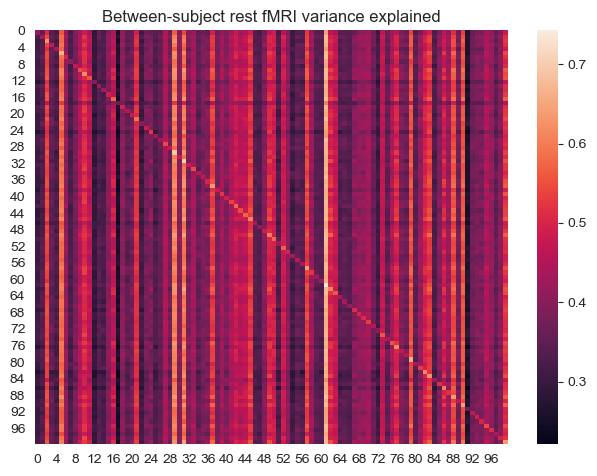

In [93]:
pca_fmri_rest = list()
pca_fmri_rest_var_exp = np.zeros((n_fmri_subj,))

for si in tqdm(range(n_fmri_subj)):
    this_fmri = fmri_rest_ts[:, :, si]
    pca = PCA(n_components=n_pc)
    pca.fit(this_fmri)

    variance_explained = {
        'each': pca.explained_variance_ratio_,
        'cumul': np.cumsum(pca.explained_variance_ratio_),
        'total': np.sum(pca.explained_variance_ratio_)
    }
    pca_fmri_rest.append({'pca': pca, 'var_exp': variance_explained})
    pca_fmri_rest_var_exp[si] = variance_explained['total']

print(f'Median within-subject variance explained (rest): {100*np.median(pca_fmri_rest_var_exp):.2f}%')

# compute inter-subject variance explained (baseline)
N = n_fmri_subj
fmri_rest_intersubj_var_exp_all = np.zeros((N, N))
for s1 in tqdm(range(N)):
    x1 = fmri_rest_ts[:, :, s1]
    p1 = pca_fmri_rest[s1]['pca']
    for s2 in range(N):
        x2 = fmri_rest_ts[:, :, s2]
        x2_pc = x2 @ p1.components_.T
        total_var = np.sum(np.power(x2, 2), axis=None)
        pc_vars = np.sum(np.power(x2_pc, 2), axis=0)
        fmri_rest_intersubj_var_exp_all[s1, s2] = np.sum(pc_vars) / total_var
triuind = np.triu_indices_from(fmri_rest_intersubj_var_exp_all, k=1)
fmri_rest_intersubj_var_exp_all_vec = fmri_rest_intersubj_var_exp_all[triuind]
fmri_rest_intersubj_var_exp = np.median(fmri_rest_intersubj_var_exp_all_vec)
print(f'Median between-subject variance explained (rest): {100*fmri_rest_intersubj_var_exp:.2f}%')

plt.figure()
sns.heatmap(fmri_rest_intersubj_var_exp_all)
plt.title('Between-subject rest fMRI variance explained')
plt.tight_layout()
plt.show()

## Project fMRI into RNN PC space


In [94]:
def project_fmri_one_model(model_idx):
    n_runs = len(pca_hidden_task[model_idx])
    fmri_task_variance_explained_model = np.zeros((n_pc, fmri_task_nsubj, n_runs))
    fmri_task_projected_model = []
    fmri_rest_variance_explained_model = np.zeros((n_pc, fmri_task_nsubj, n_runs))
    fmri_rest_projected_model = []

    for run_idx in tqdmnb(range(n_runs), desc=f'Model {model_idx+1}/{n_models}',
                        position=model_idx, leave=True):
        fmri_task_projected_run = []
        fmri_rest_projected_run = []
        for subj_idx in range(n_fmri_subj):
            
            # task
            this_fmri_task = fmri_task_ts[:, :, subj_idx]
            this_pca_task = pca_hidden_task[model_idx][run_idx]['pca']
            this_fmri_task_proj, this_fmri_task_var_exp = project_fmri_to_rnn_pc_space(
                this_fmri_task, this_pca_task, normalize_data=True)
            fmri_task_projected_run.append({
                'fmri_pc': this_fmri_task_proj,
                'variance_explained': this_fmri_task_var_exp,
                'subject': fmri_task_subjnames[subj_idx]
            })
            fmri_task_variance_explained_model[:, subj_idx, run_idx] = this_fmri_task_var_exp['each']
            
            # rest
            this_fmri_rest = fmri_rest_ts[:, :, subj_idx]
            this_pca_rest = pca_hidden_rest[model_idx][run_idx]['pca']
            this_fmri_rest_proj, this_fmri_rest_var_exp = project_fmri_to_rnn_pc_space(
                this_fmri_rest, this_pca_rest, normalize_data=True)
            fmri_rest_projected_run.append({
                'fmri_pc': this_fmri_rest_proj,
                'variance_explained': this_fmri_rest_var_exp,
                # 'subject': fmri_rest_subjnames[subj_idx]
            })
            fmri_rest_variance_explained_model[:, subj_idx, run_idx] = this_fmri_rest_var_exp['each']
            
        fmri_task_projected_model.append(fmri_task_projected_run)
        fmri_rest_projected_model.append(fmri_rest_projected_run)

    return fmri_task_projected_model, fmri_task_variance_explained_model, fmri_rest_projected_model, fmri_rest_variance_explained_model

results = Parallel(n_jobs=-1, prefer='threads')(
    delayed(project_fmri_one_model)(i) for i in range(n_models)
)

fmri_task_projected = [r[0] for r in results]
fmri_task_variance_explained = [r[1] for r in results]
fmri_rest_projected = [r[2] for r in results]
fmri_rest_variance_explained = [r[3] for r in results]

Model 5/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 1/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 7/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 4/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 11/12:   0%|          | 0/100 [00:00<?, ?it/s]

...

Model 10/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 12/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 8/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 3/12:   0%|          | 0/100 [00:00<?, ?it/s]

Model 9/12:   0%|          | 0/100 [00:00<?, ?it/s]

## Plot fMRI variance explained


100 (100%) -- GoNogo-v0-Del_200_100_Dec_300 -- Unmasked Reg. 
100 (100%) -- GoNogo-v0-Del_200_100_Dec_300 -- Masked Reg. 
100 (100%) -- GoNogo-v0-Del_200_100_Dec_300 -- Masked S-F
100 (100%) -- GoNogo-v0-Del_200_100_Dec_300 -- Masked Eucl.
100 (100%) -- GoNogo-v0-Del_200_100_Dec_300 -- Masked S-A
100 (100%) -- GoNogo-v0-Del_200_100_Dec_300 -- Masked U-T
100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Unmasked Reg. 
100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Masked Reg. 
100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Masked S-F
100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Masked Eucl.
100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Masked S-A
100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Masked U-T


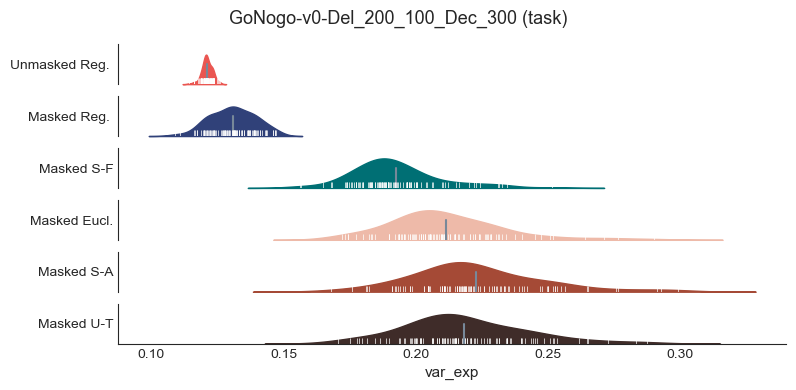

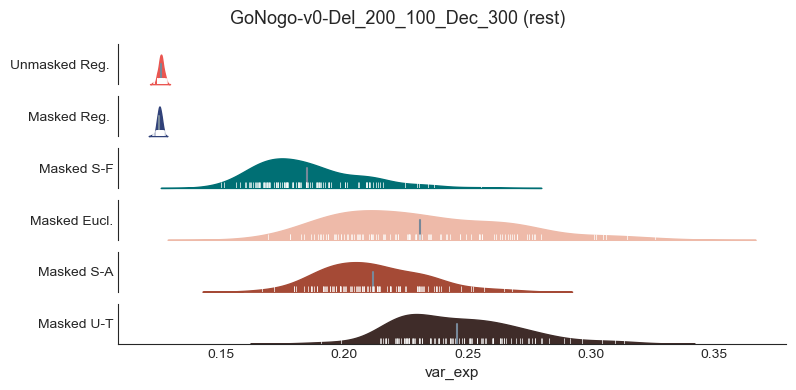

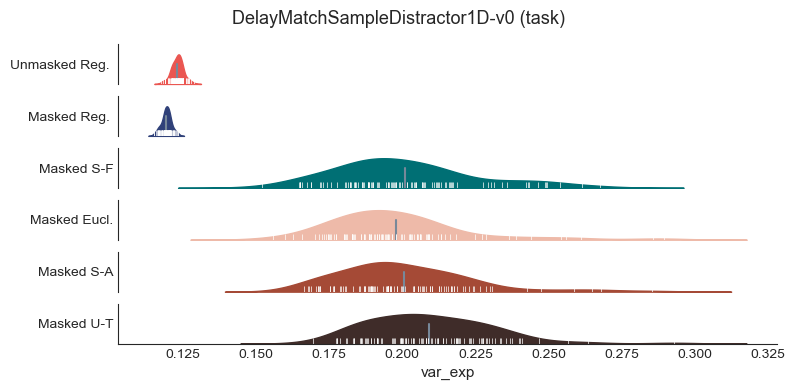

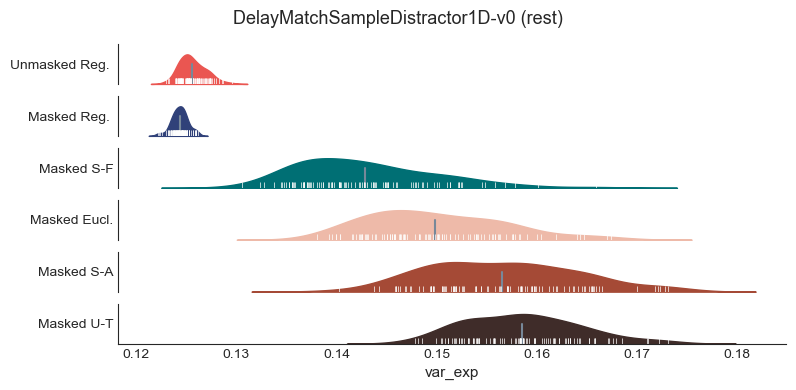

In [95]:
n_kernels_ve = len(kernel_labels)
if n_kernels_ve <= 3:
    color_palette_ve = utils.get_my_colors(cat_trio=True, as_list=True)
else:
    color_palette_ve = utils.get_my_colors(cat_trio=False, as_list=True)
# ensure we have enough colors
color_palette_ve = color_palette_ve[:n_kernels_ve]

# Build long-form DataFrame
records_task = []
records_rest = []
for task_idx in range(n_tasks):
    for model_idx in range(n_models):
        if model_params.task_no_modifier.iloc[model_idx] in task_names[task_idx]:
            this_kernel = model_params.kernel_label.iloc[model_idx]
            learned_runs = test_accuracy_pca[model_idx] > -0.1
            learned_runs_frac = sum(learned_runs) / len(test_accuracy_pca[model_idx])
            print(f'{sum(learned_runs):3d} ({int(learned_runs_frac*100):3d}%) -- {task_names[task_idx]} -- {this_kernel}')
            if learned_runs_frac > 0.4:
                data_task = (fmri_task_variance_explained[model_idx][:, :, learned_runs]
                        .mean(axis=2).sum(axis=0) / fmri_task_intersubj_var_exp)
                data_rest = (fmri_rest_variance_explained[model_idx][:, :, learned_runs]
                        .mean(axis=2).sum(axis=0) / fmri_rest_intersubj_var_exp)
            else:
                data_task = np.full((n_fmri_subj,), np.nan)
                data_rest = np.full((n_fmri_subj,), np.nan)
            for val in data_task:
                records_task.append({'kernel': this_kernel, 'task': task_names[task_idx], 'var_exp': val})
            for val in data_rest:
                records_rest.append({'kernel': this_kernel, 'task': task_names[task_idx], 'var_exp': val})

df_ve_task = pd.DataFrame(records_task)
df_ve_rest = pd.DataFrame(records_rest)
labels = ['task', 'rest']

kernel_order = list(model_params.kernel_label.unique())

for task_idx in range(n_tasks):
    for ii, df_ve in enumerate([df_ve_task, df_ve_rest]):
        df_task = df_ve[df_ve['task'] == task_names[task_idx]]
        fig = categorical_kde_plot(df_task, variable='var_exp', category='kernel',
                                category_order=kernel_order, horizontal=1,
                                color_palette=color_palette_ve, 
                                title=f'{task_names[task_idx]} ({labels[ii]})')
    

## Weight-kernel similarity vs fMRI variance explained

In [96]:
# Map kernel_type to its similarity matrix (1 - distance)
kernel_similarity_matrices = {
    'euclidean': 1 - distance_matrix_eucl,
    'sf_axis': 1 - distance_matrix_sf,
    'sa_axis': 1 - distance_matrix_sa,
    'ut_axis': 1 - distance_matrix_ut,
}

# Kernel types that have a spatial embedding (skip Vanilla / Masked Vanilla)
kernel_types_with_embedding = set(kernel_similarity_matrices.keys())

# Compute weight-kernel similarity and pair with fMRI variance explained
records_wk = []

for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    kt = this.kernel_type

    # Skip models without a spatial kernel
    if kt not in kernel_types_with_embedding:
        continue

    target_sim = kernel_similarity_matrices[kt]
    # triu_idx = np.triu_indices(hidden_size, k=1)
    # target_vec = target_sim[triu_idx]
    include_mask = ~np.eye(target_sim.shape[0], dtype=np.bool_)
    target_vec = target_sim[include_mask]

    learned_runs = test_accuracy_pca[model_idx] > -0.1 # currently not filtering out any runs

    for run_idx in range(len(trained_models_all[model_idx])):
        if not learned_runs[run_idx]:
            continue

        # Extract learned recurrent weights (full range, not absolute)
        W_hh = trained_models_all[model_idx][run_idx]['rnn'].rnn.weight_hh_l0.detach().cpu().numpy()
        # weight_vec = W_hh[triu_idx]
        # weight_vec = W_hh[include_mask]
        weight_vec = W_hh[include_mask]
        # weight_vec = np.abs(W_hh[include_mask])

        # 1. Spearman correlation
        r_spearman, _ = stats.spearmanr(weight_vec, target_vec)

        # 2. Euclidean distance (lower = more similar)
        eucl_dist = np.linalg.norm(weight_vec - target_vec)

        # 3. Cosine similarity
        cos_sim = np.dot(weight_vec, target_vec) / (np.linalg.norm(weight_vec) * np.linalg.norm(target_vec))

        # fMRI variance explained for this run (mean across subjects, sum across PCs)
        fmri_task_ve = (fmri_task_variance_explained[model_idx][:, :, run_idx]
                        .sum(axis=0).mean() / fmri_task_intersubj_var_exp)
        
        fmri_rest_ve = (fmri_rest_variance_explained[model_idx][:, :, run_idx]
                        .sum(axis=0).mean() / fmri_rest_intersubj_var_exp)
        
        # task performance for this run
        task_perf = test_data_task[model_idx][run_idx]['accuracy']

        records_wk.append({
            'task': this.task_no_modifier,
            'kernel_label': this.kernel_label,
            'kernel_type': kt,
            'model_idx': model_idx,
            'run_idx': run_idx,
            'spearman': r_spearman,
            'euclidean': eucl_dist,
            'cosine': cos_sim,
            'fmri_task_var_exp': fmri_task_ve,
            'fmri_rest_var_exp': fmri_rest_ve,
            'accuracy': task_perf,
        })

df_wk = pd.DataFrame(records_wk)
print(f'{len(df_wk)} model-runs with spatial kernels')
df_wk.groupby(['task', 'kernel_label']).size()


800 model-runs with spatial kernels


task                             kernel_label
DelayMatchSampleDistractor1D-v0  Masked Eucl.    100
                                 Masked S-A      100
                                 Masked S-F      100
                                 Masked U-T      100
GoNogo-v0                        Masked Eucl.    100
                                 Masked S-A      100
                                 Masked S-F      100
                                 Masked U-T      100
dtype: int64

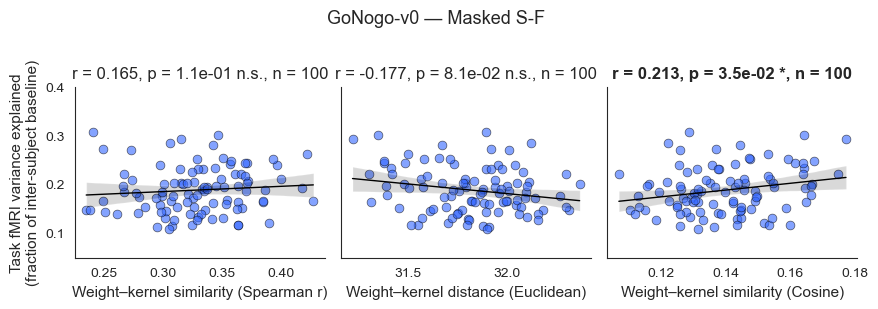

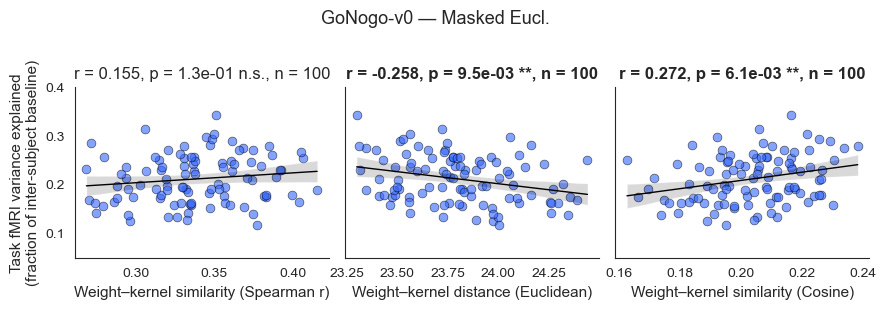

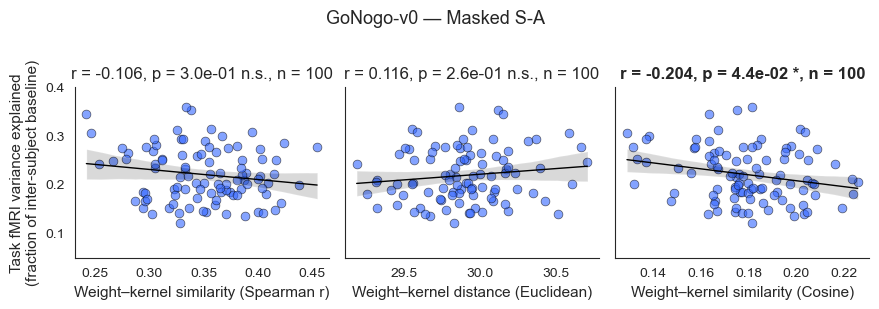

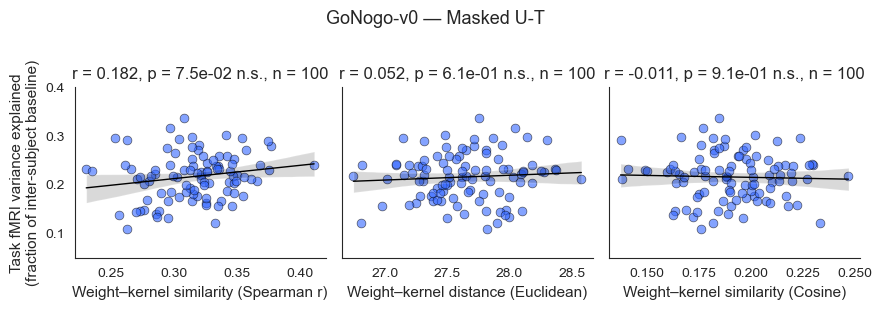

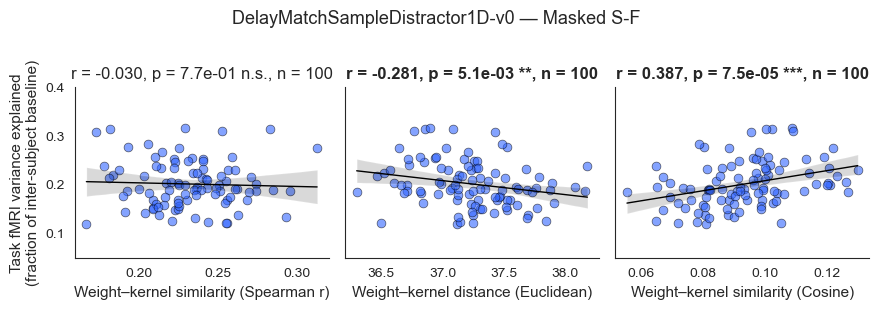

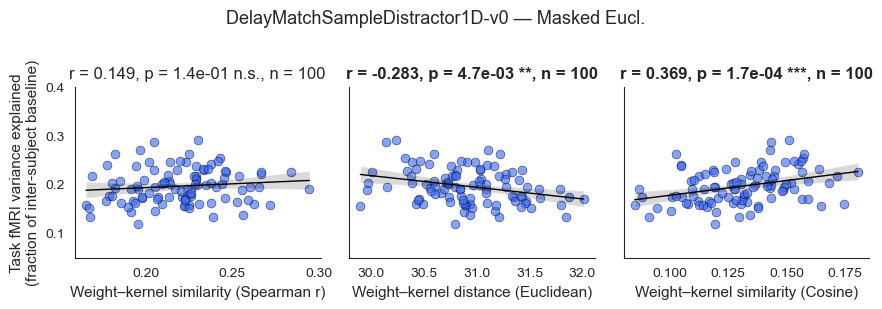

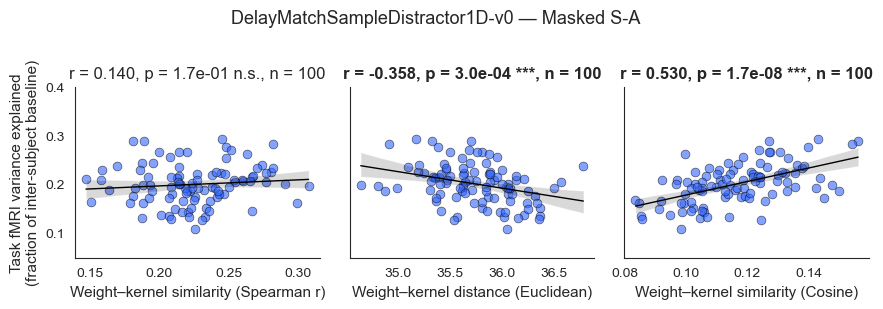

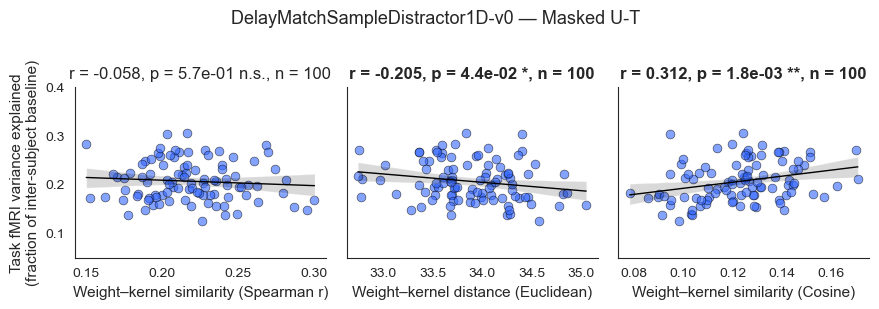

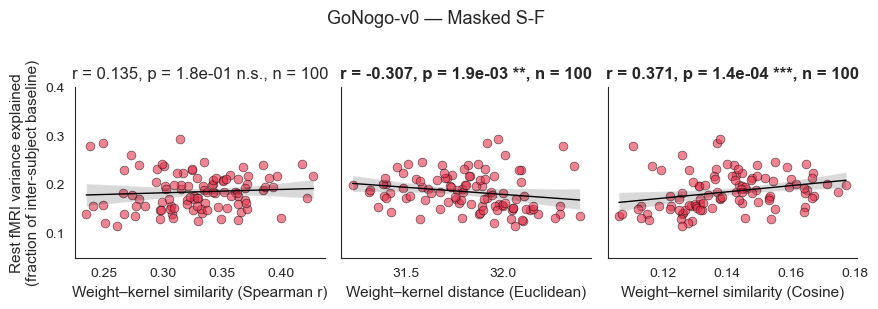

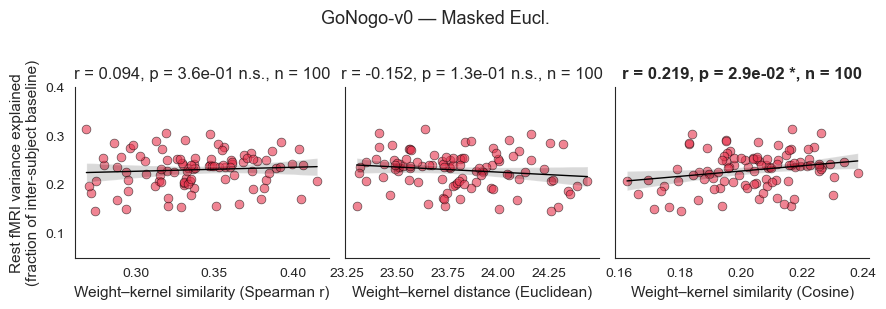

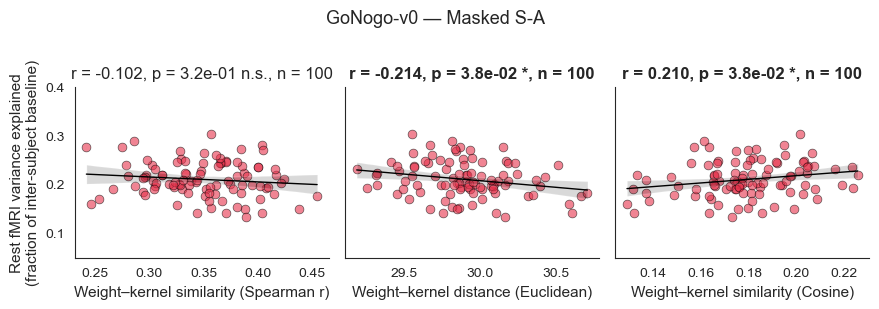

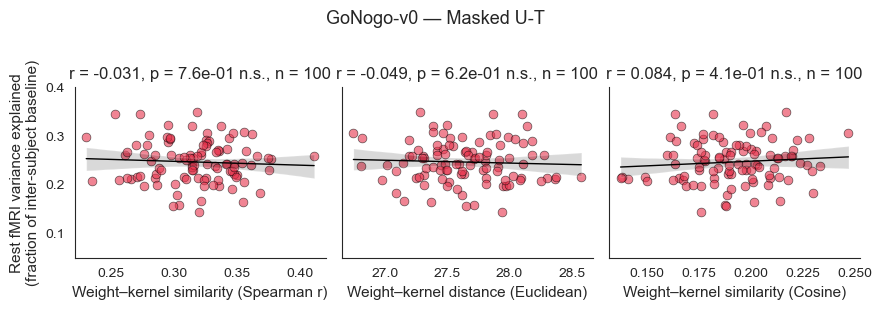

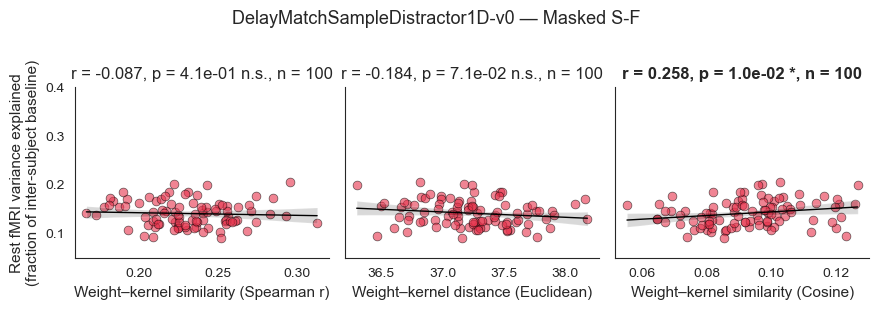

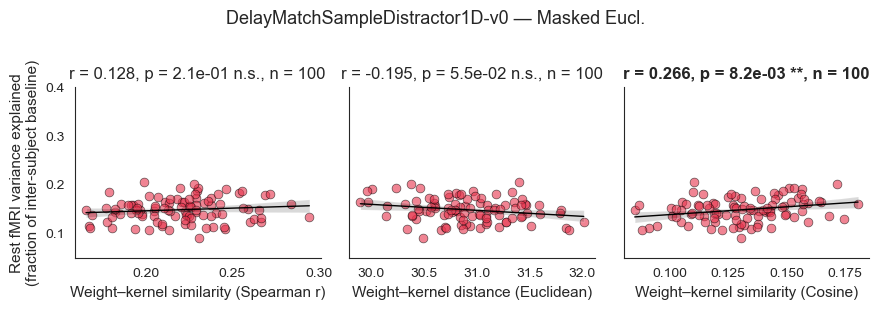

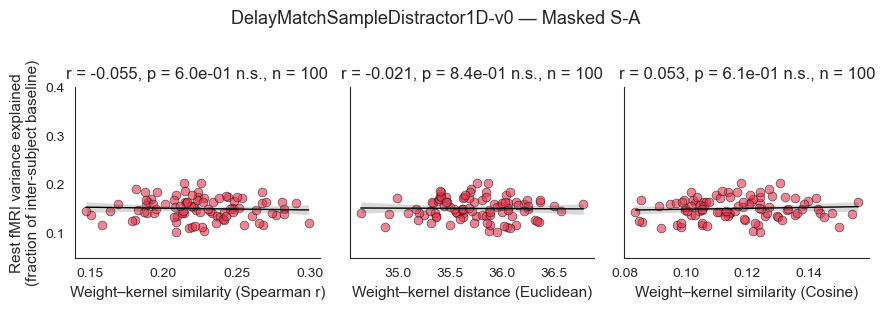

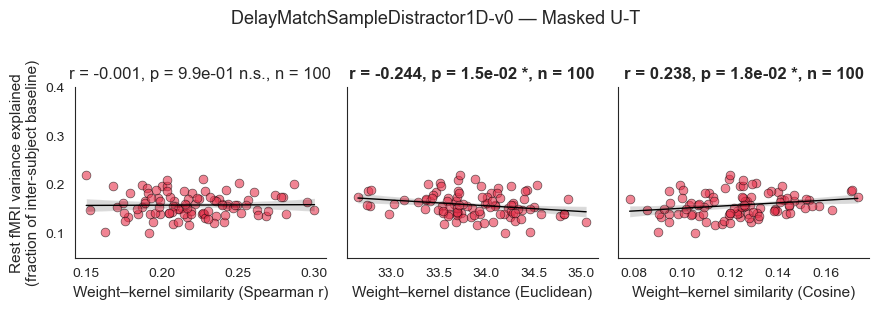

In [97]:
# Plot: one scatter per (task x kernel x metric), with regression line + CI and significance
plot_tasks = df_wk['task'].unique()
plot_kernels = df_wk['kernel_label'].unique()

metrics = {
    'spearman': 'Weight–kernel similarity (Spearman r)',
    'euclidean': 'Weight–kernel distance (Euclidean)',
    'cosine': 'Weight–kernel similarity (Cosine)',
}

font_size = 11
set_font_size(font_size)

def sig_indicator(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

plotting_y_metrics = [
    {
        'key': 'fmri_task_var_exp', 
        'ylabel': 'Task fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': '_weight_kernel_vs_fmri_task_ve',
        'color': [0.2, 0.4, 1.0]
        },
    {
        'key': 'fmri_rest_var_exp', 
        'ylabel': 'Rest fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': '_weight_kernel_vs_fmri_rest_ve',
        'color': [0.9, 0.2, 0.3]
        },
    # {
    #     'key': 'accuracy', 
    #     'ylabel': 'RNN task accuracy',
    #     'file_suff': '_weight_kernel_vs_task_accuracy',
    #.    'color': [0.5, 0.5, 0.5]
    #     }
]

for y_metric_idx in range(len(plotting_y_metrics)):
    
    y_metric_key = plotting_y_metrics[y_metric_idx]['key']
    y_metric_ylabel = plotting_y_metrics[y_metric_idx]['ylabel']
    y_metric_file_suff = plotting_y_metrics[y_metric_idx]['file_suff']
    y_metric_color = plotting_y_metrics[y_metric_idx]['color']
    
    
    for task in plot_tasks:
        
        # figw = 10
        # figh = figw / 4 * len(plot_kernels)
        # fig, axes = plt.subplots(nrows=len(plot_kernels), ncols=len(metrics), figsize=(figw,figh), 
        #                          squeeze=True, sharex=True, sharey=True)
        
        for kernel in plot_kernels:
            df_sub = df_wk[(df_wk['task'] == task) & (df_wk['kernel_label'] == kernel)]
            if len(df_sub) < 3:
                continue

            fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=True)
            ax_i = 0
            
            for ax, (metric, xlabel) in zip(axes, metrics.items()):
                x = df_sub[metric].values
                y = df_sub[y_metric_key].values
                
                x_mad = sp.stats.median_abs_deviation(x)
                y_mad = sp.stats.median_abs_deviation(y)
                x_modz = (x-np.median(x))/x_mad
                y_modz = (y-np.median(y))/y_mad
                modz_thr = 4
                excl = np.any(np.stack((x_modz < -modz_thr, 
                                        x_modz > modz_thr,
                                        y_modz < -modz_thr,
                                        y_modz > modz_thr)), 
                              axis=0)
                x = x[~excl]
                y = y[~excl]

                r, p = stats.spearmanr(x, y)

                # regression line with 95% CI via seaborn
                sns.regplot(x=x, y=y, ax=ax, scatter=True, color=y_metric_color, 
                            scatter_kws={'s': 40, 'alpha': 0.6, 'edgecolors':'k', 'linewidths': 0.5},
                            line_kws={'color': 'k', 'linewidth': 1},
                            ci=95)

                ax.set_xlabel(xlabel)
                if ax_i == 0:
                    ax.set_ylabel(y_metric_ylabel)
                ax.set_ylim((0.05,0.4))
                sig = sig_indicator(p)
                title_str = f'r = {r:.3f}, p = {p:.1e} {sig}, n = {len(df_sub)}'
                ax.set_title(title_str, fontweight='bold' if sig != 'n.s.' else 'normal')
                
                ax_i += 1

            fig.suptitle(f'{task} — {kernel}', y=1.02)
            sns.despine(fig=fig, offset=0, trim=False)
            fig.tight_layout()

            if save_figs:
                fig.savefig(os.path.join(outdir, f'{task}_{kernel}_{y_metric_file_suff}.svg'),
                            dpi=600, bbox_inches='tight', pad_inches=0.01)

            plt.show()


# Variance analysis


In [99]:
# set up weight masks
masks = get_weight_masks_schaefer(
    roi_names=list(pd.read_csv(eucl_kernel_file)[:hidden_size]['ROI Name']),
    input_system='Vis', output_system='Default')

kernel_types_var = model_params.kernel_type.unique().tolist()
kernel_labels_var = model_params.kernel_label.unique().tolist()
n_kernels_var = len(kernel_labels_var)

# define node groups to analyze
node_group_masks = {
    'input': masks['input_weight_mask'],
    'internal': masks['bystanders'],
    'output': masks['output_weight_mask']
}

# compute variance metrics across models for each task and node group
n_runs_var = min(len(test_data_task[m]) for m in range(n_models))
variance_by_task = {}

for task_idx in range(n_tasks):
    variance_by_group = {}
    for group_name, group_mask in node_group_masks.items():
        variance_by_group[group_name] = {
            'task_var': np.zeros((n_kernels_var, n_runs_var)),
            'temp_var': np.zeros((n_kernels_var, n_runs_var)),
            'spat_var': np.zeros((n_kernels_var, n_runs_var)),
            'mean_act': np.zeros((n_kernels_var, n_runs_var)),
        }

        for model_idx in tqdm(range(n_models), desc=f'Computing variance ({task_names[task_idx]}, {group_name} nodes)'):
            this = model_params.iloc[model_idx]
            if this.task_no_modifier not in task_names[task_idx]:
                continue
            k_idx = this.kernel_index

            for run in range(n_runs_var):
                ha = np.array(test_data_task[model_idx][run]['hidden_activity'])
                task_variance = compute_task_variance(hidden_activity=ha, mask=group_mask)
                variance_by_group[group_name]['task_var'][k_idx, run] = task_variance['hidden_activity_task_var'].mean()
                variance_by_group[group_name]['temp_var'][k_idx, run] = task_variance['hidden_activity_temp_var'].mean()
                variance_by_group[group_name]['spat_var'][k_idx, run] = task_variance['hidden_activity_spat_var'].mean()
                variance_by_group[group_name]['mean_act'][k_idx, run] = task_variance['hidden_activity_mean'].mean()

    variance_by_task[task_names[task_idx]] = variance_by_group

Computing variance (GoNogo-v0-Del_200_100_Dec_300, input nodes): 100%|██████████| 12/12 [00:00<00:00, 42.97it/s]
Computing variance (GoNogo-v0-Del_200_100_Dec_300, internal nodes): 100%|██████████| 12/12 [00:00<00:00, 25.39it/s]
Computing variance (GoNogo-v0-Del_200_100_Dec_300, output nodes): 100%|██████████| 12/12 [00:00<00:00, 48.03it/s]
Computing variance (DelayMatchSampleDistractor1D-v0, input nodes): 100%|██████████| 12/12 [00:00<00:00, 12.30it/s]
Computing variance (DelayMatchSampleDistractor1D-v0, internal nodes): 100%|██████████| 12/12 [00:01<00:00,  9.76it/s]
Computing variance (DelayMatchSampleDistractor1D-v0, output nodes): 100%|██████████| 12/12 [00:00<00:00, 20.66it/s]


In [ ]:
n_kernels_var = len(kernel_labels_var)
if n_kernels_var <= 3:
    color_palette_var = utils.get_my_colors(cat_trio=True, as_list=True)
else:
    color_palette_var = utils.get_my_colors(cat_trio=False, as_list=True)
# ensure we have enough colors
color_palette_var = color_palette_var[:n_kernels_var]

metric_keys = ['mean_act', 'task_var', 'temp_var', 'spat_var']
metric_labels = ['Mean activity', 'Task variance', 'Temporal variance', 'Spatial variance']

kernel_order_var = list(model_params.kernel_label.unique())

for task_idx in range(n_tasks):
    variance_by_group = variance_by_task[task_names[task_idx]]

    for group_name in ['internal']:  # node_group_masks:
        print(f'\n=== {task_names[task_idx]} — {group_name} nodes ===')

        for metric_key, label in zip(metric_keys, metric_labels):
            plot_data = variance_by_group[group_name][metric_key]
            if label == 'Mean activity':
                df = pd.DataFrame(data=np.abs(plot_data.T), columns=kernel_labels_var)
            else:
                df = pd.DataFrame(data=plot_data.T, columns=kernel_labels_var)
            df = pd.melt(df)
            df.columns = ['RNN', label]
            fig = categorical_kde_plot(df, variable=label, category="RNN",
                                       category_order=kernel_order_var,
                                       horizontal=1, color_palette=color_palette_var)

            fig.suptitle(f'{task_names[task_idx]} — {group_name} nodes', y=1.02, fontsize=10)
            if save_figs:
                fig.savefig(os.path.join(outdir, '{0}_{1}_node_{2}.svg'.format(
                    task_names[task_idx], group_name, label.replace(" ", "_"))),
                    dpi=600, bbox_inches='tight', pad_inches=0.01)

# INTs analysis


## Compute ACF


In [ ]:
dynamic_keys = ['acw_50', 'acw_0', 'aca_50', 'aca_0']

def compute_ac_one_model(model_task_data, model_rest_data, n_nodes, n_trials):
    n_runs = len(model_task_data)
    n_time_task = model_task_data[0]['hidden_activity'][0].shape[0]
    n_lags_task = n_time_task - 1
    n_lags_rest = 100

    ac_model_task = []
    ac_model_rest = []

    for run in range(n_runs):

        ac_run_task = {'ac': np.zeros((n_nodes, n_lags_task, n_trials))}
        for k in dynamic_keys:
            ac_run_task[k] = np.zeros((n_nodes, n_trials))

        ac_run_rest = {'ac': np.zeros((n_nodes, n_lags_rest))}
        for k in dynamic_keys:
            ac_run_rest[k] = np.zeros((n_nodes,))

        for node in range(n_nodes):
            for trial in range(n_trials):
                ts = model_task_data[run]['hidden_activity'][trial][:, node]
                ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_task)
                ac_run_task['ac'][node, :, trial] = ac
                ac_run_task['acw_50'][node, trial] = acw_50
                ac_run_task['acw_0'][node, trial] = acw_0
                ac_run_task['aca_50'][node, trial] = aca_50
                ac_run_task['aca_0'][node, trial] = aca_0

            ts = model_rest_data[run]['hidden_activity'][:, node]
            ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_rest)
            ac_run_rest['ac'][node, :] = ac
            ac_run_rest['acw_50'][node] = acw_50
            ac_run_rest['acw_0'][node] = acw_0
            ac_run_rest['aca_50'][node] = aca_50
            ac_run_rest['aca_0'][node] = aca_0

        ac_model_task.append(ac_run_task)
        ac_model_rest.append(ac_run_rest)

    return ac_model_task, ac_model_rest


with tqdm_joblib(tqdm(total=n_models), desc='Calculating AC'):
    results = Parallel(n_jobs=-1)(
        delayed(compute_ac_one_model)(
            test_data_task[model_idx],
            test_data_rest[model_idx],
            n_nodes,
            n_trials
        )
        for model_idx in range(n_models)
    )

ac_data_task = [r[0] for r in results]
ac_data_rest = [r[1] for r in results]

## Plot ACF


In [ ]:
size_scale = 2
font_size = int(5 * size_scale)
set_font_size(font_size)
n_fig_columns = min((3, n_tasks))
n_fig_rows = math.ceil(n_tasks / n_fig_columns)
fig_size_w = 2.5 * n_fig_columns * size_scale
fig_size_h = 2 * n_fig_rows * size_scale

plotting_data = [
    [ac_data_task, 'task'],
    [ac_data_rest, 'rest']
]

n_runs_plot = n_runs

for i in range(len(plotting_data)):
    for kernel_idx in range(n_kernels):

        f_ac, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                               squeeze=True, sharex=True, sharey=True)

        for model_idx in range(n_models):
            if model_params.loc[model_idx, 'kernel_index'] == kernel_idx:
                task_index = model_params.loc[model_idx, 'task_index']
                n_runs_plot = min(n_runs_plot, len(test_data_task[model_idx]))

                f_ac.axes[task_index].axhline(y=0, color='k', linewidth=1.)

                this_data = plotting_data[i][0]
                n_lags = this_data[model_idx][0]['ac'].shape[1]
                y_plot = np.zeros((n_nodes, n_lags, n_runs_plot))

                for run in range(n_runs_plot):
                    run_data = this_data[model_idx][run]['ac']
                    if run_data.ndim == 3:
                        y_plot[:, :, run] = np.nanmean(run_data, axis=2)
                    else:
                        y_plot[:, :, run] = run_data

                y_plot = np.squeeze(np.nanmean(y_plot, axis=2))

                for node in range(n_nodes):
                    f_ac.axes[task_index].plot(y_plot[node, :], color=colors[node, :],
                                              linewidth=0.5, alpha=1)
                f_ac.axes[task_index].set_title(model_params.loc[model_idx, 'task_label'])

        f_ac.axes[0].set_ylim((-1, 1))
        f_ac.suptitle(kernel_labels[kernel_idx] + ' (' + plotting_data[i][1] + ')')
        sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
        f_ac.tight_layout()
        plt.show()

        if save_figs:
            suff = '{:}_{:}'.format(task_names[0], model_params.rnn_model.iloc[0])
            f_ac.savefig(os.path.join(outdir, 'acf_{:}_masks-{:}_{:}_{:}.svg'.format(
                suff, model_params.mask_weights.iloc[kernel_idx],
                plotting_data[i][1], model_params.kernel_type.iloc[kernel_idx])),
                dpi=300, bbox_inches='tight', pad_inches=0.01)


## ACW and ACA violin plots


In [ ]:
plotting_data_acw = [
    [ac_data_rest, 'rest']
]
plotting_keys = ['acw_0'] # ['acw_50', 'acw_0', 'aca_50', 'aca_0']

size_scale = 5
font_size = int(5 * size_scale)
set_font_size(font_size)
n_fig_columns = min((3, n_tasks))
n_fig_rows = math.ceil(n_tasks / n_fig_columns)
fig_size_w = 5 * n_fig_columns * size_scale
fig_size_h = 2 * n_fig_rows * size_scale

for i in range(len(plotting_data_acw)):
    for j in range(len(plotting_keys)):

        f_ac, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                               squeeze=True, sharex=True, sharey=False)

        for task_index in range(n_tasks):

            this_task_models = model_params[model_params['task_index'] == task_index]
            plotting_df = pd.DataFrame()
            ax = f_ac.axes[task_index]

            for model_idx in range(len(this_task_models)):

                this_model_data = plotting_data_acw[i][0][this_task_models.iloc[model_idx].model_index]
                this_model_kernel = this_task_models.iloc[model_idx].kernel_label
                this_model_task = this_task_models.iloc[model_idx].task_label

                y_plot = np.zeros((n_nodes, len(this_model_data)))
                n_runs_here = len(this_model_data)
                for run in range(n_runs_here):
                    run_data = this_model_data[run][plotting_keys[j]]
                    if run_data.ndim == 2:
                        y_plot[:, run] = run_data.mean(axis=1)
                    else:
                        y_plot[:, run] = run_data

                y_plot = np.squeeze(y_plot.mean(axis=1))

                this_plotting_df = pd.DataFrame({
                    'y': y_plot,
                    'task': this_model_task,
                    'kernel': np.repeat(this_model_kernel, n_nodes),
                    'node_group': node_groups_labels
                })
                plotting_df = pd.concat([plotting_df, this_plotting_df], ignore_index=True)

            # create violin plot
            hue_order = ['in', 'inter', 'out']
            palette = dict(zip(hue_order, np.flip(colors_categ, axis=0)))
            sns.violinplot(x='kernel', y='y', hue='node_group', data=plotting_df,
                          linewidth=1, cut=0, saturation=1, inner='box', dodge=True,
                          palette=palette, hue_order=hue_order, order=kernel_labels,
                          ax=ax)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_title(task_names[task_index])
            for x in ax.get_xticks()[:-1]+0.5: 
                ax.axvline(x=x, color=[0.7]*3)
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

        f_ac.suptitle(plotting_keys[j] + ' (' + plotting_data_acw[i][1] + ')')
        sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
        f_ac.tight_layout()
        plt.show()


## fMRI AC and INTs

In [ ]:
ac_data_fmri = []
dynamic_keys = ['acw_0'] # ['acw_50','acw_0','aca_50','aca_0']
n_lags_rest = 100

for subj in tqdm(range(n_fmri_subj), desc='Computing AC for fMRI'):
        
        # initialize arrays of AC, ACW, and ACA values for this subject
        ac_subj_rest = dict()
        ac_subj_rest['ac'] = np.zeros((n_nodes,n_lags_rest,))
        for k in dynamic_keys:
            ac_subj_rest[k] = np.zeros((n_nodes,))
        
        # nodes loop
        for node in range(n_nodes):
            
            # get values for rest
            ts = fmri_rest_ts[:,node,subj]
            ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_rest)
            ac_subj_rest['ac'][node,:] = ac
            for k in dynamic_keys:
                ac_subj_rest[k][node] = globals()[k]
        
        # append this subject's data 
        ac_data_fmri.append(ac_subj_rest)

In [ ]:
plotting_keys_fmri = ['acw_0']  # ['acw_50', 'acw_0', 'aca_50', 'aca_0']

size_scale = 1.5
font_size = int(6 * size_scale)
set_font_size(font_size)
n_fig_columns = 1
n_fig_rows = 1
fig_size_w = 4 * n_fig_columns * size_scale
fig_size_h = 2 * n_fig_rows * size_scale

for j in range(len(plotting_keys_fmri)):

    f_ac, ax = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                             squeeze=True)

    plotting_df = pd.DataFrame()

    for subj in range(n_fmri_subj):
        subj_data = ac_data_fmri[subj]

        y_plot = subj_data[plotting_keys_fmri[j]]
        if y_plot.ndim == 2:
            y_plot = y_plot.mean(axis=1)
        y_plot = np.squeeze(y_plot)

        this_plotting_df = pd.DataFrame({
            'y': y_plot,
            'subject': np.repeat(subj, n_nodes),
            'kernel': np.repeat('fMRI', n_nodes),
            'node_group': node_groups_labels
        })
        plotting_df = pd.concat([plotting_df, this_plotting_df], ignore_index=True)

    # average across subjects per node, then build a single-row df
    plotting_df = plotting_df.groupby(['kernel', 'node_group'], sort=False).agg({'y': 'mean'}).reset_index()
    # re-expand: one row per node with mean across subjects
    mean_per_node = np.mean([ac_data_fmri[s][plotting_keys_fmri[j]] for s in range(n_fmri_subj)], axis=0)
    plotting_df = pd.DataFrame({
        'y': mean_per_node,
        'kernel': np.repeat('fMRI', n_nodes),
        'node_group': node_groups_labels
    })

    # create violin plot
    hue_order = ['in', 'inter', 'out']
    palette = dict(zip(hue_order, np.flip(colors_categ, axis=0)))
    sns.violinplot(x='kernel', y='y', hue='node_group', data=plotting_df,
                   linewidth=1, cut=0, saturation=1, inner='box', dodge=True,
                   palette=palette, hue_order=hue_order,
                   ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('fMRI')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    f_ac.suptitle(plotting_keys_fmri[j] + ' (fMRI)')
    sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    f_ac.tight_layout()
    plt.show()


## Correlation between fMRI and RNN INTs

In [ ]:
int_keys = ['acw_0']  # extend as needed: ['acw_0', 'aca_0', 'acw_50', 'aca_50']
node_selection = np.isin(node_groups, [1,]) # <<<<< select nodes here
font_size = 12
set_font_size(font_size)

# Compute mean fMRI INT per node (average across subjects)
fmri_mean = {}
for key in int_keys:
    fmri_mean[key] = np.mean([ac_data_fmri[s][key] for s in range(n_fmri_subj)], axis=0)[node_selection]

# Compute mean RNN INT per node per model (average across runs)
rnn_mean = {}
for key in int_keys:
    rnn_mean[key] = []
    for model_idx in range(n_models):
        runs = ac_data_rest[model_idx]
        model_avg = np.mean([run[key] for run in runs], axis=0)[node_selection]
        rnn_mean[key].append(model_avg)

# Plot: one figure per INT key, one subplot per model
for key in int_keys:
    fig, axes = plt.subplots(n_models, 1, figsize=(5, n_models * 5 ), 
                             squeeze=False, sharex=False, sharey=True)
    axes = axes.ravel()

    for model_idx in range(n_models):
        ax = axes[model_idx]
        x = rnn_mean[key][model_idx]
        y = fmri_mean[key]

        r, p = stats.spearmanr(x, y)

        ax.scatter(x, y, c=colors[node_selection], s=50, alpha=1.0, edgecolors='k')
        # fit and plot regression line
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1)

        ax.set_xlabel(f'RNN {key}')
        ax.set_ylabel(f'fMRI {key}')
        title = f"{model_params.loc[model_idx, 'task_label']} | {model_params.loc[model_idx, 'kernel_label']}"
        ax.set_title(f'{title}\nr={r:.3f}, p={p:.1e}')

    fig.suptitle(f'Node-level {key}: fMRI vs RNN', y=1.02)
    sns.despine(fig=fig, offset=0, trim=False)
    fig.tight_layout()
    plt.show()

In [ ]:
int_keys = ['acw_0']  # extend as needed: ['acw_0', 'aca_0', 'acw_50', 'aca_50']
set_font_size()

n_kernels_corr = len(kernel_labels)
if n_kernels_corr <= 3:
    color_palette_corr = utils.get_my_colors(cat_trio=True, as_list=True)
else:
    color_palette_corr = utils.get_my_colors(cat_trio=False, as_list=True)
color_palette_corr = color_palette_corr[:n_kernels_corr]

kernel_order = list(model_params.kernel_label.unique())

for key in int_keys:
    records = []
    for model_idx in range(n_models):
        this_kernel = model_params.loc[model_idx, 'kernel_label']
        this_task = model_params.loc[model_idx, 'task']
        for run_data in ac_data_rest[model_idx]:
            rnn_vals = run_data[key]
            run_records = []
            for subj in range(n_fmri_subj):
                fmri_vals = ac_data_fmri[subj][key]
                mask_valid = ~np.isnan(rnn_vals) & ~np.isnan(fmri_vals)
                if mask_valid.sum() > 2:
                    r, _ = stats.spearmanr(rnn_vals[mask_valid], fmri_vals[mask_valid])
                else:
                    r = np.nan
                run_records.append(r)
            run_records = np.array(run_records)
            records.append({'kernel': this_kernel, 'task': this_task, 'corr': np.median(run_records)})

    df_corr = pd.DataFrame(records).dropna(subset=['corr'])

    for task_idx in range(n_tasks):
        df_task = df_corr[df_corr['task'] == task_names[task_idx]]
        fig = categorical_kde_plot(df_task, variable='corr', category='kernel',
                                   category_order=kernel_order, horizontal=1,
                                   color_palette=color_palette_corr,
                                   title=f'{task_names[task_idx]} — {key} (Spearman r)',
                                   rug=1, refline=0, ttest=True)